In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,index,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,7.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,16.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,16.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,17.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,19.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [4]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'index', 'department', 'aisle', 'First Name',
       'Surnam', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='object')

In [5]:
top10_departments = df_instacart['department'].value_counts().head(10)

In [6]:

dept_income = df_instacart.groupby('department')['prices'].sum()
top10_income = dept_income.sort_values(ascending=False).head(10)

print(top10_income)


department
dairy eggs      10550189.8
produce          3271821.5
beverages         873008.9
frozen            783501.7
pantry            646305.8
snacks            507811.4
meat seafood      491044.6
bakery            379071.3
canned goods      352408.8
deli              344083.8
Name: prices, dtype: float64


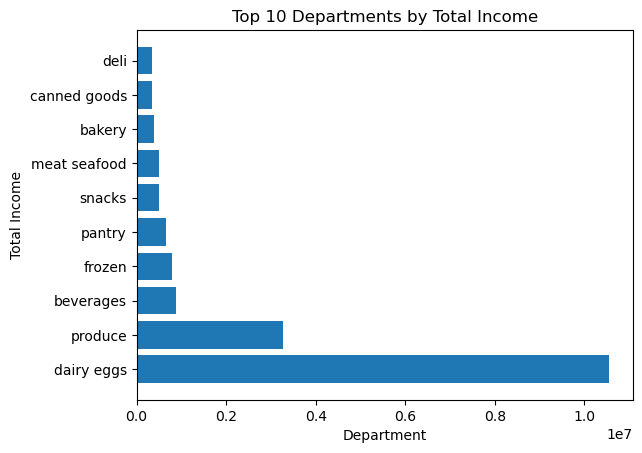

In [7]:
plt.figure()
plt.barh( top10_income.index, top10_income.values)
plt.title('Top 10 Departments by Total Income') 
plt.xlabel('Department')
plt.ylabel('Total Income')
plt.show()

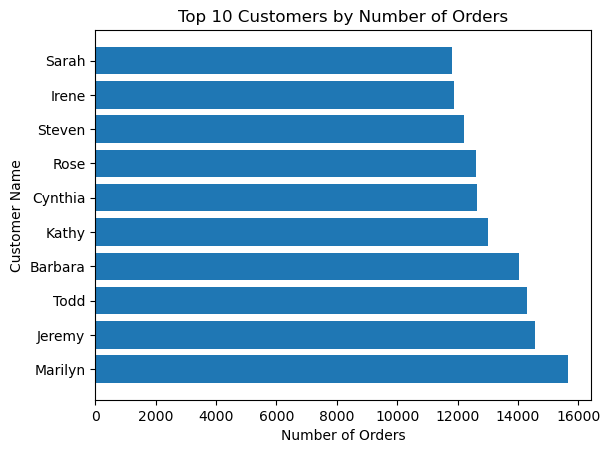

In [17]:
Top_customers=df_instacart.groupby("First Name")["order_id"].count().sort_values(ascending=False).head(10)
plt.figure()
plt.barh(Top_customers.index, Top_customers.values)
plt.title('Top 10 Customers by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')
plt.show()

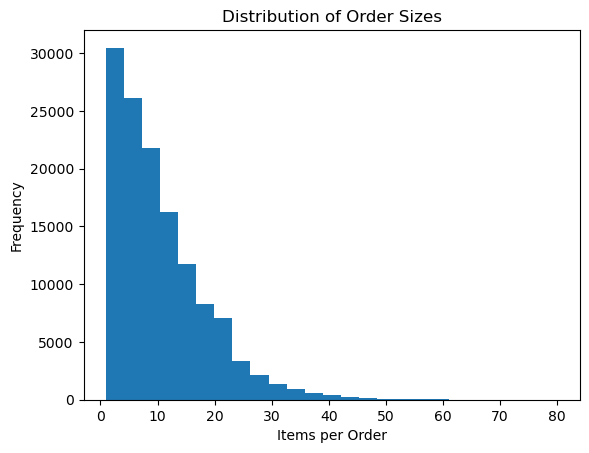

In [28]:
order_sizes = df_instacart.groupby('order_id').size()

plt.hist(order_sizes, bins=25)
plt.xlabel("Items per Order")
plt.ylabel("Frequency")
plt.title("Distribution of Order Sizes")
plt.show()